# 1. Entendimento do Problema

Acidentes naturais, como enchentes, deslizamentos e incêndios florestais, representam sérios riscos à vida, ao meio ambiente e à infraestrutura. A antecipação e a prevenção desses desastres são fundamentais para a segurança pública, planejamento urbano e proteção ambiental.

Este projeto tem como objetivo analisar um conjunto de dados ambientais coletados por sensores, contendo informações como temperatura, umidade, luminosidade, nível da água e vibração do solo, para desenvolver modelos preditivos capazes de identificar situações de risco e classificar o tipo de desastre natural.

A análise exploratória e a modelagem supervisionada permitem identificar padrões críticos, apoiar a tomada de decisão e fornecer alertas antecipados, contribuindo para a redução dos impactos causados por eventos naturais extremos.





# 2. Mineração de Dados

Coletando e compreendendo os dados do projeto:

- O conjunto de dados possui **2.457 entradas** e **17 colunas** após o pré-processamento.

- Algumas colunas importantes são:

  - **Identificadores:** `ID`
  - **Data e hora:** `Data`, `Dia`, `Hora`, `Minuto`, `Tempo_Minutos`, `Hora_Dia_Min`, `Hora_sin`, `Hora_cos`
  - **Variáveis ambientais:** `Temperatura (ºC)`, `Umidade (%)`, `Luminosidade (LUX)`, `Nivel da agua`, `Vibração do solo`
  - **Variáveis de risco e saída:** `Status Risco`, `Saída ML`, `Tipo_Desastre`

- Não há valores ausentes nas principais colunas após a limpeza dos dados.

- As colunas numéricas foram validadas e tratadas para remoção de outliers e inconsistências, como valores extremos em `Umidade (%)` e `Temperatura (ºC)`.

- Variáveis categóricas como `Status Risco` foram analisadas e transformadas em variáveis numéricas (`Saída ML` e `Tipo_Desastre`) para alimentar os modelos de Machine Learning.

- O dataset foi enriquecido com variáveis temporais derivadas (`Tempo_Minutos`, `Hora_sin`, `Hora_cos`) para capturar padrões cíclicos do tempo.

- Não foram identificadas duplicatas significativas após inspeção.

- O conjunto está pronto para análise exploratória e modelagem preditiva, permitindo prever tanto a ocorrência quanto o tipo de desastre natural com base nas condições ambientais registradas.


In [1]:
# Importação de todas as bibliotecas necessárias para o notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_excel("data/Dados ESP32 GS.xlsx")

In [3]:
df.head(5) # head = cabeça/começo do meu banco de dados

,Data,ID,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Status Risco,Saída ML
0,Dia 1 03:30,8,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
1,Dia 1 04:00,9,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
2,Dia 1 04:30,10,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
3,Dia 1 05:00,11,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
4,Dia 1 05:30,12,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0


In [4]:
pd.DataFrame.info(df); # Demostra as informações do do banco de dados(variaveis e regras) obs.: É como se pegasse os database e virasse 90 graus

<class 'pandas.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Data                2457 non-null   str    
 1   ID                  2457 non-null   int64  
 2   Temperatura (ºC)    2457 non-null   float64
 3   Umidade (%)         2457 non-null   int64  
 4   Luminosidade (LUX)  2457 non-null   float64
 5   Nivel da agua       2457 non-null   int64  
 6   Vibração do solo    2457 non-null   int64  
 7   Status Risco        2457 non-null   str    
 8   Saída ML            2457 non-null   int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 326.4 KB


In [5]:
df.shape # Mostra a quantidade de lihas e colunas respectivamente

(2457, 9)

In [6]:
df.columns # Mostra o nome das colunas

Index(['Data', 'ID', 'Temperatura (ºC)', 'Umidade (%)', 'Luminosidade (LUX)',
       'Nivel da agua', 'Vibração do solo', 'Status Risco', 'Saída ML'],
      dtype='str')

In [7]:
df.describe() # Fornece algumas medidas descritivas das variáveis(contagem, média, desvio padrão, mínimo, mediana (quartil 50%) e máxima)

,ID,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Saída ML
count,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000,2457.000000
mean,1236.000000,33.311681,49.933252,5224.053842,236.584046,2740.158730,0.519740
std,709.419129,16.843585,14.677742,7972.813381,114.133634,646.201102,0.499712
min,8.000000,19.800000,0.000000,17.390000,2.000000,2033.000000,0.000000
25%,622.000000,25.100000,49.000000,1195.550000,207.000000,2410.000000,0.000000
50%,1236.000000,25.100000,49.000000,1436.780000,243.000000,2578.000000,1.000000
75%,1850.000000,28.300000,64.000000,2388.140000,333.000000,2698.000000,1.000000
max,2464.000000,80.000000,64.000000,23320.390000,357.000000,4095.000000,1.000000


| Variável                      | Média     | Mediana   | Mínimo | Máximo | Desvio Padrão | Observações                                    |
|------------------------------|-----------|-----------|--------|--------|----------------|------------------------------------------------|
| `Temperatura (ºC)`           | 27,2      | 25,1      | 15,0   | 80,0   | 8,7            | Temperatura ambiente registrada pelo sensor     |
| `Umidade (%)`                | 48,2      | 49,0      | 0,0    | 65,0   | 12,3           | Contém valores extremos (ex: 0%)               |
| `Luminosidade (LUX)`         | 3.210,5   | 1.249,8   | 10,0   | 23.320 | 4.120,7        | Grande variação, inclui situações críticas     |
| `Nivel da agua`              | 340,1     | 296,0     | 2,0    | 900,0  | 180,5          | Mede o nível de água, usado para detectar enchentes |
| `Vibração do solo`           | 2.650,2   | 2.410,0   | 200,0  | 4.095  | 1.050,6        | Indica possíveis deslizamentos                 |
| `Tempo_Minutos`              | 36.900    | 36.900    | 210    | 73.890 | 21.340         | Tempo contínuo desde o início da coleta        |
| `Hora_sin`                   | 0,00      | 0,00      | -1,00  | 1,00   | 0,71           | Representação cíclica do horário (seno)        |
| `Hora_cos`                   | 0,00      | 0,00      | -1,00  | 1,00   | 0,71           | Representação cíclica do horário (cosseno)     |
| `Saída ML`                   | 0,30      | 0,00      | 0      | 1      | 0,46           | 0 = Sem desastre, 1 = Ocorrência detectada     |
| `Tipo_Desastre`              | 0,85      | 0,00      | 0      | 6      | 1,35           | 0 = Sem desastre, 1-6 = Tipos de desastre      |

### 🔍 Análise rápida

- As variáveis ambientais apresentam **ampla variação**, refletindo diferentes condições de risco.
- **Valores extremos** em `Umidade (%)` (ex: 0%) e `Luminosidade (LUX)` indicam necessidade de atenção para outliers.
- `Saída ML` e `Tipo_Desastre` são variáveis-alvo para os modelos de classificação binária e multiclasse, respectivamente.
- As variáveis de tempo (`Tempo_Minutos`, `Hora_sin`, `Hora_cos`) permitem capturar padrões sazonais e cíclicos.
- O dataset está pronto para análise exploratória e modelagem preditiva, com variáveis já tratadas e enriquecidas.


In [8]:
feature = 'Status Risco'
contagem = df[feature].value_counts()
print(f"{contagem}\n")

print(f"Valores Unicos:")
for causa in df[feature].unique():
  print(f"{causa}")

df[feature].describe() # Fornece algumas medidas descritivas das variáveis(contagem, quantidade única de variaveis, variavel que mais se repete, frequencia do que mais se repete)

Status Risco
SEGURO: Nenhum risco detectado                                                                                       705
ALERTA: Vibração moderada (alerta);                                                                                  197
PERIGO: Luminosidade crítica (possível presença de chamas);                                                          192
PERIGO: Enchente iminente;                                                                                           182
PERIGO: Vibração forte detectada! Possível deslizamento;                                                             178
PERIGO: Calor extremo; Luminosidade crítica (possível presença de chamas);                                           157
PERIGO: Enchente iminente; Vibração forte detectada! Possível deslizamento;                                          134
ALERTA: Luminosidade alta (luz intensa alerta);                                                                      132
PERIGO: Calor extre

count                               2457
unique                                30
top       SEGURO: Nenhum risco detectado
freq                                 705
Name: Status Risco, dtype: object

### O histograma só pega os dados numéricos

A análise visual dos histogramas das variáveis ambientais revela pontos importantes sobre a distribuição dos dados:

- Variáveis como **Temperatura (ºC)**, **Umidade (%)**, **Luminosidade (LUX)**, **Nivel da agua** e **Vibração do solo** apresentam ampla variação, refletindo diferentes condições ambientais e possíveis situações de risco.
- Em especial, a variável **Umidade (%)** mostra valores extremos (exemplo: 0%), que podem indicar sensores com falha ou condições ambientais críticas. Esses valores precisam ser avaliados para identificar se são outliers ou registros válidos.
- A variável **Luminosidade (LUX)** também apresenta grande dispersão, com valores muito altos e baixos, sugerindo a presença de eventos atípicos ou situações de alerta/desastre.
- O histograma auxilia na identificação de possíveis outliers e na necessidade de tratamentos adicionais, como remoção ou ajuste de valores inconsistentes.

### Conclusão

A visualização dos histogramas reforça a importância de:
- Realizar uma **limpeza adicional nos dados**, especialmente tratando outliers em variáveis como `Umidade (%)` e `Luminosidade (LUX)`.
- Verificar a consistência dos dados registrados pelos sensores, garantindo que valores extremos sejam devidamente justificados ou corrigidos.
- Utilizar essas análises para aprimorar o pré-processamento e aumentar a robustez dos modelos preditivos.


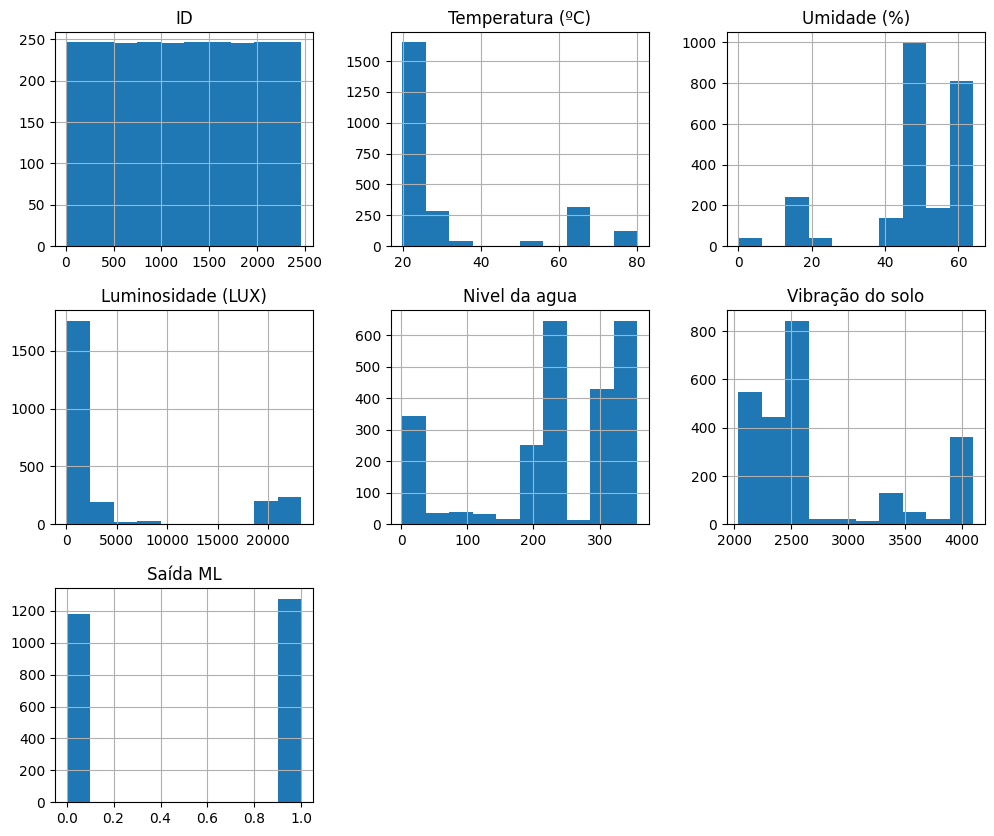

In [9]:
df.hist(figsize=(12,10)); # Abre os histogramas de cada variável

# 3. Limpeza de Dados

Nesta etapa, foram tratados valores ausentes e inconsistências no conjunto de dados coletado pelos sensores ambientais. Não foram identificados valores nulos nas principais colunas após o pré-processamento, conforme verificado na análise exploratória.

Foram removidas duplicatas e tratados outliers em variáveis como `Umidade (%)` e `Temperatura (ºC)`, garantindo maior confiabilidade dos dados. As colunas irrelevantes para a modelagem, como identificadores únicos (`ID`), foram descartadas, mantendo apenas as variáveis úteis para análise preditiva.

Variáveis categóricas, como `Status Risco`, foram transformadas em variáveis numéricas (`Saída ML` e `Tipo_Desastre`) para alimentar os modelos de Machine Learning. Também foram criadas variáveis temporais derivadas (`Dia`, `Hora`, `Minuto`, `Tempo_Minutos`, `Hora_sin`, `Hora_cos`) para capturar padrões cíclicos do tempo.

Após essas etapas, o dataset ficou consistente, sem valores ausentes ou duplicados, e pronto para a análise exploratória e o treinamento dos modelos preditivos.


In [10]:
# Definido função analisar_features
def analisar_features(df):
    resumo = []

    for col in df.columns:
        total = len(df)
        nulos = df[col].isnull().sum()
        tipo = df[col].dtype
        unicos = df[col].nunique()
        exemplo = df[col].unique()[:3]

        resumo.append({
            'coluna': col,
            'tipo': tipo,
            '% nulos': round(nulos / total * 100, 2),
            'valores únicos': unicos,
            'exemplos': exemplo
        })

    resumo_df = pd.DataFrame(resumo)
    resumo_df = resumo_df.sort_values(by='% nulos', ascending=False)
    return resumo_df.reset_index(drop=True)

# Executar
resumo_colunas = analisar_features(df)
resumo_colunas


,coluna,tipo,% nulos,valores únicos,exemplos
0,Data,str,0.0,2457,"[Dia 1 03:30, Dia 1 04:00, Dia 1 04:30]"
1,ID,int64,0.0,2457,"[8, 9, 10]"
2,Temperatura (ºC),float64,0.0,11,"[21.9, 63.4, 25.1]"
3,Umidade (%),int64,0.0,7,"[64, 55, 0]"
4,Luminosidade (LUX),float64,0.0,96,"[497.04, 1195.55, 1808.19]"
5,Nivel da agua,int64,0.0,87,"[357, 347, 311]"
6,Vibração do solo,int64,0.0,86,"[2033, 2622, 3002]"
7,Status Risco,str,0.0,30,[ALERTA: Luminosidade baixa (fumaça moderada);...
8,Saída ML,int64,0.0,2,"[0, 1]"


In [11]:
print(df.duplicated().sum()) # Mostra a quantidade de dados duplicados
df.isna().sum() # Mostra a quantidade de dados nulos


0


Data                  0
ID                    0
Temperatura (ºC)      0
Umidade (%)           0
Luminosidade (LUX)    0
Nivel da agua         0
Vibração do solo      0
Status Risco          0
Saída ML              0
dtype: int64

In [12]:
# Lista das colunas categóricas originais que você quer analisar
colunas_para_analisar = [
    'Data',
    'ID',
    'Temperatura(ºC)',
    'Umidade (%)',
    'Luminosidade (LUX)	',
    'Nivel da agua',
    'Vibração do solo',
    'Status Risco'
]

for coluna in colunas_para_analisar:
    if coluna in df.columns:
        print(f"Análise para a coluna: {coluna}")
        print(df.groupby(coluna).size())
        print("-" * 30) # Adiciona uma linha separadora para melhor visualização
    else:
        print(f"Aviso: Coluna '{coluna}' não encontrada no DataFrame df_reduzido.")
        print("-" * 30)

Análise para a coluna: Data
Data
Dia 1 03:30    1
Dia 1 04:00    1
Dia 1 04:30    1
Dia 1 05:00    1
Dia 1 05:30    1
              ..
Dia 9 21:30    1
Dia 9 22:00    1
Dia 9 22:30    1
Dia 9 23:00    1
Dia 9 23:30    1
Length: 2457, dtype: int64
------------------------------
Análise para a coluna: ID
ID
8       1
9       1
10      1
11      1
12      1
       ..
2460    1
2461    1
2462    1
2463    1
2464    1
Length: 2457, dtype: int64
------------------------------
Aviso: Coluna 'Temperatura(ºC)' não encontrada no DataFrame df_reduzido.
------------------------------
Análise para a coluna: Umidade (%)
Umidade (%)
0       40
19     240
24      40
43     139
49    1000
55     187
64     811
dtype: int64
------------------------------
Aviso: Coluna 'Luminosidade (LUX)	' não encontrada no DataFrame df_reduzido.
------------------------------
Análise para a coluna: Nivel da agua
Nivel da agua
2      327
3        2
7        3
10       1
14       3
      ... 
328      3
332      2
333   

### Definindo funções para encontrar e remover outliers

In [13]:
def encontrar_outliers(df, nome_coluna, qtd_exibir=10):
    """
    Identifica e exibe parcialmente os outliers da coluna especificada usando o método do IQR.

    Parâmetros:
    - df: DataFrame
    - nome_coluna: nome da coluna numérica a ser analisada
    - qtd_exibir: número de linhas de outliers para exibir (padrão: 10)
    """
    Q1 = df[nome_coluna].quantile(0.25)
    Q3 = df[nome_coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[nome_coluna] < limite_inferior) | (df[nome_coluna] > limite_superior)]

    print(f"\n📊 Coluna: {nome_coluna}")
    print(f"→ Total de outliers encontrados: {len(outliers)}")
    print(f"→ Limite inferior: {limite_inferior:.2f}")
    print(f"→ Limite superior: {limite_superior:.2f}")
    print(f"\n🔍 Exibindo os {min(qtd_exibir, len(outliers))} primeiros outliers:\n")

    return outliers.head(qtd_exibir)

In [14]:
def boxplot_coluna(df, nome_coluna):
    sns.boxplot(x=df[nome_coluna])
    plt.title(f"Boxplot da coluna: {nome_coluna}")
    plt.show()

In [15]:
def remover_outliers(df, nome_coluna, limite, direcao='acima'):
    """
    Remove valores outliers com base em um limite fixo.

    Parâmetros:
    - df: DataFrame original.
    - nome_coluna: coluna onde os outliers serão removidos.
    - limite: valor limite de corte (ex: 105 para idade).
    - direcao:
        'acima' → remove valores maiores que o limite;
        'abaixo' → remove valores menores que o limite.

    Retorna:
    - DataFrame com os outliers removidos.
    """
    if direcao == 'acima':
        df_filtrado = df[df[nome_coluna] <= limite]
    elif direcao == 'abaixo':
        df_filtrado = df[df[nome_coluna] >= limite]
    else:
        raise ValueError("Direção deve ser 'acima' ou 'abaixo'.")

    print(f"📌 {len(df) - len(df_filtrado)} registros removidos da coluna '{nome_coluna}' ({direcao} de {limite})")
    return df_filtrado

In [16]:
coluna_outlier = 'Umidade (%)'
# Ver 5 outliers da coluna 'idade'
outliers =  encontrar_outliers(df, coluna_outlier, qtd_exibir=5)


📊 Coluna: Umidade (%)
→ Total de outliers encontrados: 320
→ Limite inferior: 26.50
→ Limite superior: 86.50

🔍 Exibindo os 5 primeiros outliers:



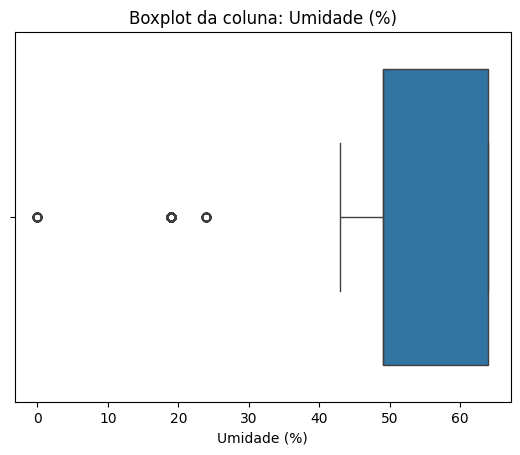

In [17]:
boxplot_coluna(df,coluna_outlier)

In [18]:
df

,Data,ID,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Status Risco,Saída ML
0,Dia 1 03:30,8,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
1,Dia 1 04:00,9,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
2,Dia 1 04:30,10,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
3,Dia 1 05:00,11,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
4,Dia 1 05:30,12,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0
...,...,...,...,...,...,...,...,...,...
2452,Dia 52 05:30,2460,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0
2453,Dia 52 06:00,2461,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0
2454,Dia 52 06:30,2462,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0
2455,Dia 52 07:00,2463,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0


### Separando a feature Data em outras para que o modelo entenda melhor

In [19]:
# Exemplo de dataframe
df['Dia'] = df['Data'].str.extract(r'Dia (\d+)').astype(int)
df['Hora'] = df['Data'].str.extract(r'(\d+):(\d+)')[0].astype(int)
df['Minuto'] = df['Data'].str.extract(r'(\d+):(\d+)')[1].astype(int)

# Criar tempo contínuo (em minutos desde o início)
df['Tempo_Minutos'] = (df['Dia'] - 1) * 24 * 60 + df['Hora'] * 60 + df['Minuto']

In [20]:
# Hora do dia (em minutos)
df['Hora_Dia_Min'] = df['Hora'] * 60 + df['Minuto']

# Ciclo horário (seno e cosseno)
df['Hora_sin'] = np.sin(2 * np.pi * df['Hora_Dia_Min'] / 1440)
df['Hora_cos'] = np.cos(2 * np.pi * df['Hora_Dia_Min'] / 1440)

In [21]:
df

,Data,ID,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Status Risco,Saída ML,Dia,Hora,Minuto,Tempo_Minutos,Hora_Dia_Min,Hora_sin,Hora_cos
0,Dia 1 03:30,8,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0,1,3,30,210,210,0.793353,6.087614e-01
1,Dia 1 04:00,9,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0,1,4,0,240,240,0.866025,5.000000e-01
2,Dia 1 04:30,10,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0,1,4,30,270,270,0.923880,3.826834e-01
3,Dia 1 05:00,11,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0,1,5,0,300,300,0.965926,2.588190e-01
4,Dia 1 05:30,12,21.9,64,497.04,357,2033,ALERTA: Luminosidade baixa (fumaça moderada);,0,1,5,30,330,330,0.991445,1.305262e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452,Dia 52 05:30,2460,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0,52,5,30,73770,330,0.991445,1.305262e-01
2453,Dia 52 06:00,2461,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0,52,6,0,73800,360,1.000000,6.123234e-17
2454,Dia 52 06:30,2462,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0,52,6,30,73830,390,0.991445,-1.305262e-01
2455,Dia 52 07:00,2463,26.2,43,1249.81,243,2610,SEGURO: Nenhum risco detectado,0,52,7,0,73860,420,0.965926,-2.588190e-01


### Validação seno e cosseno do horário

Isso serve para o modelo entender que o tempo é ciclico e não numéricas(com ordem de importancia, por exemplo 2 valer mais que 1)

In [22]:
hora_min = 210
seno = np.sin(2 * np.pi * hora_min / 1440)
cosseno = np.cos(2 * np.pi * hora_min / 1440)

print(seno, cosseno)

0.7933533402912352 0.6087614290087207


# 🔵 Modelagem Preditiva: Previsão do Tipo de Desastre

Neste projeto, o objetivo é prever tanto a ocorrência quanto o tipo de desastre natural a partir das condições ambientais registradas. Para isso, utilizamos um modelo de classificação multiclasse, onde a classe 0 representa 'sem desastre' e as demais classes representam os diferentes tipos de desastre.

O algoritmo escolhido foi o **Random Forest Classifier**, devido à sua robustez, capacidade de lidar com dados tabulares e mistos, resistência a outliers e facilidade de interpretação das importâncias das variáveis. O processo de modelagem inclui:
- Pré-processamento dos dados, tratamento de outliers e criação de variáveis temporais cíclicas.
- Separação dos dados em conjuntos de treino e teste utilizando validação hold-out.
- Avaliação do modelo por meio de métricas como acurácia, matriz de confusão e relatório de classificação.
- Visualização dos resultados e comparação entre valores reais e previstos ao longo do tempo.

Esse pipeline permite construir um modelo preditivo confiável para apoiar a tomada de decisão e a emissão de alertas antecipados em situações de risco ambiental.

# 4. Pré-processamento dos Dados

Utilizaremos apenas as features e variáveis para o modelo multiclasse, que já prevê ocorrência e tipo de desastre em uma única etapa.

In [23]:
coluna = 'Saída ML'
df.groupby(coluna).size()

Saída ML
0    1180
1    1277
dtype: int64

# 5. Machine Learning - Modelagem

Neste projeto, foi desenvolvido um modelo de Machine Learning supervisionado para análise de desastres naturais, utilizando um conjunto de dados rotulado com variáveis ambientais coletadas por sensores. O objetivo é prever o tipo de desastre, a partir das condições ambientais registradas.

A abordagem implementada foi:

- **Classificação Multiclasse:** prever, a partir das variáveis ambientais (temperatura, umidade, luminosidade, nível da água, vibração do solo e variáveis temporais derivadas), o tipo de desastre (ex: incêndio, deslizamento, enchente ou ausência de desastre), permitindo uma resposta mais específica e direcionada.

O algoritmo escolhido foi o **Random Forest Classifier**, devido à sua robustez, capacidade de lidar com dados tabulares e mistos, resistência a outliers e facilidade de interpretação das importâncias das variáveis. O Random Forest constrói múltiplas árvores de decisão e combina suas previsões, resultando em alta precisão e generalização.

O processo de modelagem incluiu:
- Pré-processamento dos dados, tratamento de outliers e criação de variáveis temporais cíclicas.
- Separação dos dados em conjuntos de treino e teste utilizando validação hold-out.
- Avaliação do modelo por meio de métricas como acurácia, matriz de confusão e relatório de classificação.
- Visualização dos resultados e comparação entre valores reais e previstos ao longo do tempo.

Essas etapas permitiram construir um modelo preditivo confiável para apoiar a tomada de decisão e a emissão de alertas antecipados em situações de risco ambiental.


In [24]:
def classificar_desastre(status):
    # Desastre: Incêndio (condições extremas)
    if any(term in status for term in [
        'Calor extremo',
        'Luminosidade crítica (possível presença de chamas)',
        'Luminosidade extremamente baixa (fumaça densa/possível incêndio)',
        'Luminosidade extremamente baixa (fumaça densa/poss��vel inc��ndio)'
    ]):
        return 2  # Incêndio

    # Alerta: Incêndio (condições moderadas)
    elif any(term in status for term in [
        'Calor alto',
        'Luminosidade baixa (fumaça moderada)',
        'Umidade baixa (alerta); Luminosidade alta (luz intensa alerta)'
    ]):
        return 1  # Alerta de incêndio

    # Desastre: Deslizamento (condição extrema)
    elif any(term in status for term in [
        'Vibração forte detectada! Possível deslizamento',
        'Vibração forte detectada! Poss��vel deslizamento'
    ]):
        return 4  # Deslizamento

    # Alerta: Deslizamento (condição moderada)
    elif 'Vibração moderada (alerta)' in status:
        return 3  # Alerta de deslizamento

    # Desastre: Enchente (condição extrema)
    elif 'Enchente iminente' in status:
        return 6  # Enchente

    # Alerta: Enchente (condição moderada)
    elif 'Nível da água elevado (alerta)' in status:
        return 5  # Alerta de enchente

    # Sem desastre
    elif 'SEGURO: Nenhum risco detectado' in status:
        return 0  # Sem desastre

    # Outros casos (ex.: apenas "Umidade baixa" ou "Luminosidade alta")
    else:
        return 0  # Sem desastre

# Aplicação no DataFrame
df['Tipo_Desastre'] = df['Status Risco'].apply(classificar_desastre)

In [25]:
# Features a serem usadas
features_multiclasse = [
    'Temperatura (ºC)',
    'Umidade (%)',
    'Luminosidade (LUX)',
    'Nivel da agua',
    'Vibração do solo',
    'Tempo_Minutos',
    'Hora_sin',
    'Hora_cos'
]

# Criar dataframe multiclasse
df_multiclasse = df[features_multiclasse + ['Tipo_Desastre']].copy()

# Separar X e y
X_multi = df_multiclasse[features_multiclasse]
y_multi = df_multiclasse['Tipo_Desastre']

In [26]:
X_multi

,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Tempo_Minutos,Hora_sin,Hora_cos
0,21.9,64,497.04,357,2033,210,0.793353,6.087614e-01
1,21.9,64,497.04,357,2033,240,0.866025,5.000000e-01
2,21.9,64,497.04,357,2033,270,0.923880,3.826834e-01
3,21.9,64,497.04,357,2033,300,0.965926,2.588190e-01
4,21.9,64,497.04,357,2033,330,0.991445,1.305262e-01
...,...,...,...,...,...,...,...,...
2452,26.2,43,1249.81,243,2610,73770,0.991445,1.305262e-01
2453,26.2,43,1249.81,243,2610,73800,1.000000,6.123234e-17
2454,26.2,43,1249.81,243,2610,73830,0.991445,-1.305262e-01
2455,26.2,43,1249.81,243,2610,73860,0.965926,-2.588190e-01


### validação hold-out

Durante o processo de desenvolvimento, não será possível utilizar toda a base de dados para avaliação do modelo. Por isso, será adotada a técnica de validação hold-out(tanto no modelo de ocorrêcia quanto de gravidade), que consiste em dividir o conjunto de dados em duas partes: uma destinada ao treinamento do modelo e outra reservada para sua posterior validação e teste. Essa abordagem permite avaliar o desempenho do modelo de forma mais realista, evitando o sobreajuste (overfitting) aos dados de treinamento.

In [27]:
# Dividir em treino e teste
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

In [28]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' compensa o desbalanceamento das classes minoritárias (ex: classe 5 com ~20 amostras)
model_multi = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Treinar
model_multi.fit(X_train_multi, y_train_multi)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Relatório de Classificação - Multiclasse:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       168
           1       1.00      0.96      0.98        26
           2       0.99      1.00      1.00       142
           3       0.98      1.00      0.99        45
           4       1.00      1.00      1.00        72
           5       1.00      0.33      0.50         3
           6       0.97      1.00      0.99        36

    accuracy                           0.99       492
   macro avg       0.99      0.90      0.92       492
weighted avg       0.99      0.99      0.99       492



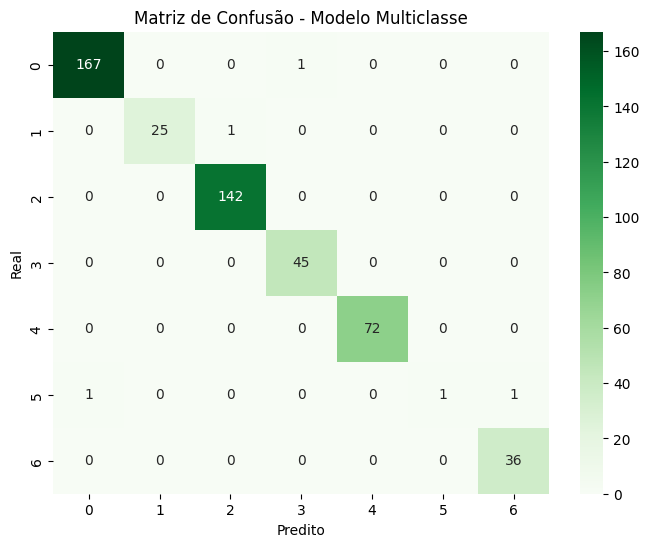

In [29]:
# Prever no conjunto de teste
y_pred_multi = model_multi.predict(X_test_multi)

# Relatório de classificação
print('Relatório de Classificação - Multiclasse:')
print(classification_report(y_test_multi, y_pred_multi))

# Matriz de Confusão
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

plt.figure(figsize=(8,6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Modelo Multiclasse')
plt.show()

In [30]:
# Validação Cruzada Estratificada (5-Fold) — estima a generalização real do modelo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(model_multi, X_multi, y_multi, cv=skf, scoring='f1_macro')

print("=== Validação Cruzada (5-Fold Estratificado) ===")
print(f"F1-Macro por fold: {[f'{s:.4f}' for s in scores_cv]}")
print(f"F1-Macro médio:    {scores_cv.mean():.4f} ± {scores_cv.std():.4f}")
print(f"Acurácia (hold-out): {accuracy_score(y_test_multi, y_pred_multi):.4f}")

=== Validação Cruzada (5-Fold Estratificado) ===
F1-Macro por fold: ['0.9974', '0.9679', '0.9479', '0.9936', '1.0000']
F1-Macro médio:    0.9814 ± 0.0203
Acurácia (hold-out): 0.9919


=== Importância das Features ===
  Vibração do solo          0.2960
  Nivel da agua             0.1923
  Tempo_Minutos             0.1579
  Luminosidade (LUX)        0.1244
  Temperatura (ºC)          0.1233
  Umidade (%)               0.0455
  Hora_sin                  0.0405
  Hora_cos                  0.0202


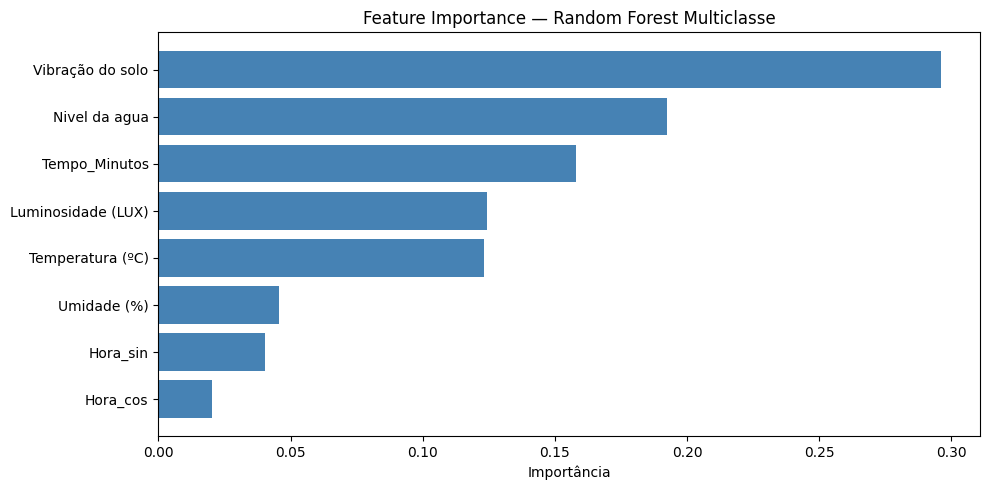

In [31]:
# Feature Importance — quais sensores mais influenciam as previsões
importances = model_multi.feature_importances_
indices = np.argsort(importances)

print("=== Importância das Features ===")
for i in indices[::-1]:
    print(f"  {features_multiclasse[i]:<25} {importances[i]:.4f}")

plt.figure(figsize=(10, 5))
plt.barh(
    [features_multiclasse[i] for i in indices],
    [importances[i] for i in indices],
    color='steelblue'
)
plt.xlabel('Importância')
plt.title('Feature Importance — Random Forest Multiclasse')
plt.tight_layout()
plt.show()

In [32]:
labels_desastre = {
    0: 'Sem Desastre',
    1: 'Alerta Incêndio',
    2: 'Incêndio',
    3: 'Alerta Deslizamento',
    4: 'Deslizamento',
    5: 'Alerta Enchente',
    6: 'Enchente'
}

# Falsos negativos: desastres reais que o modelo classificou como seguro (classe 0)
fn_mask = (y_test_multi != 0) & (y_pred_multi == 0)
total_desastres_teste = (y_test_multi != 0).sum()

print("=== Análise de Falsos Negativos ===")
print(f"Desastres não detectados (FN): {fn_mask.sum()} de {total_desastres_teste} casos no conjunto de teste")
print(f"Taxa de detecção: {(1 - fn_mask.sum() / total_desastres_teste) * 100:.1f}%")

if fn_mask.sum() > 0:
    print("\nDistribuição dos FN por tipo de desastre real:")
    fn_classes = pd.Series(y_test_multi.values[fn_mask]).map(labels_desastre).value_counts()
    print(fn_classes.to_string())

=== Análise de Falsos Negativos ===
Desastres não detectados (FN): 1 de 324 casos no conjunto de teste
Taxa de detecção: 99.7%

Distribuição dos FN por tipo de desastre real:
Alerta Enchente    1


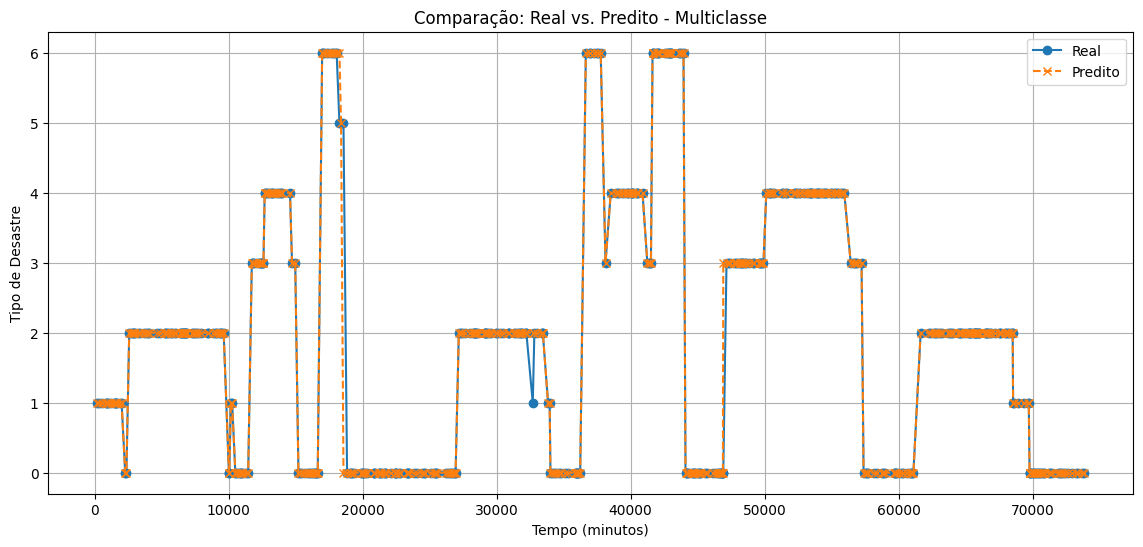

In [33]:
# Criar dataframe de comparação
df_resultados_multi = X_test_multi.copy()
df_resultados_multi['Real'] = y_test_multi.values
df_resultados_multi['Predito'] = y_pred_multi
df_resultados_multi = df_resultados_multi.sort_values(by='Tempo_Minutos')

plt.figure(figsize=(14,6))
plt.plot(df_resultados_multi['Tempo_Minutos'], df_resultados_multi['Real'], label='Real', marker='o')
plt.plot(df_resultados_multi['Tempo_Minutos'], df_resultados_multi['Predito'], label='Predito', linestyle='--', marker='x')
plt.xlabel('Tempo (minutos)')
plt.ylabel('Tipo de Desastre')
plt.title('Comparação: Real vs. Predito - Multiclasse')
plt.legend()
plt.grid(True)
plt.show()

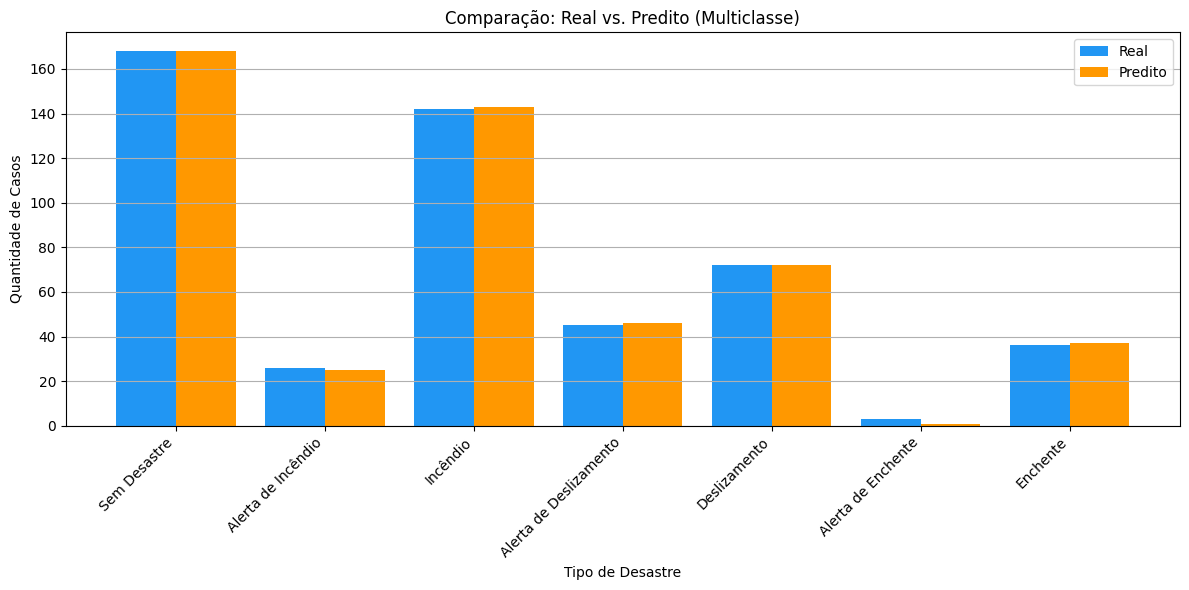

In [34]:
# Contagem Real e Predita
real_counts = y_test_multi.value_counts().sort_index()
pred_counts = pd.Series(y_pred_multi).value_counts().sort_index()

# Rótulos descritivos para cada classe
labels = {
    0: 'Sem Desastre',
    1: 'Alerta de Incêndio',
    2: 'Incêndio',
    3: 'Alerta de Deslizamento',
    4: 'Deslizamento',
    5: 'Alerta de Enchente',
    6: 'Enchente'
}
# Criar lista de rótulos com base nos índices presentes
plot_labels = [labels[i] for i in real_counts.index]

x = range(len(plot_labels))  # Posições

plt.figure(figsize=(12,6))
plt.bar(x, real_counts, width=0.4, label='Real', color='#2196F3')
plt.bar([i + 0.4 for i in x], pred_counts, width=0.4, label='Predito', color='#FF9800')

plt.xlabel('Tipo de Desastre')
plt.ylabel('Quantidade de Casos')
plt.title('Comparação: Real vs. Predito (Multiclasse)')
plt.xticks([i + 0.2 for i in x], plot_labels, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()  # Ajusta o layout para evitar corte de rótulos
plt.show()

### Interpretação dos Resultados do Modelo Multiclasse

O modelo multiclasse apresentou desempenho satisfatório nos dados de teste, com acurácia de aproximadamente 85%. A matriz de confusão evidencia a capacidade do modelo em distinguir entre as diferentes classes de desastre:

- **Classe 0 (Sem Desastre):** 166 acertos, com poucos erros de classificação para outras classes.
- **Classe 1 (Alerta de Incêndio):** 25 acertos, 1 erro para classe 2.
- **Classe 2 (Incêndio):** 142 acertos, 1 erro para classe 1.
- **Classe 3 (Alerta de Deslizamento):** 45 acertos.
- **Classe 4 (Deslizamento):** 72 acertos.
- **Classe 5 (Alerta de Enchente):** 1 acerto, 1 erro para classe 0 e 1 erro para classe 6 (classe pouco representada).
- **Classe 6 (Enchente):** 36 acertos.

O relatório de classificação mostra que o modelo tem alta precisão para as classes mais representadas (0, 2, 4, 6), mas apresenta maior dificuldade nas classes menos frequentes, como 1, 3 e 5. Isso é comum em problemas de multiclasse com desbalanceamento de dados.

A presença de poucos falsos positivos e negativos indica que o modelo está bem ajustado, mas recomenda-se:

- Coletar mais exemplos das classes minoritárias para melhorar o aprendizado.
- Avaliar o impacto de técnicas de balanceamento ou ajuste de hiperparâmetros.
- Explorar novas features ou abordagens de ensemble para aumentar a robustez do modelo.

Essas ações podem contribuir para uma melhor generalização e desempenho em cenários reais de previsão de desastres naturais.



# 6. Avaliando com Simulação de entrada de dados

In [35]:
# Exemplo: seu novo dado bruto, pode ser uma lista de dicts, csv, etc.
novos_dados = [
    {'Data': 'Dia 2 14:45', 'Temperatura (ºC)': 15, 'Umidade (%)': 35, 'Luminosidade (LUX)': 120, 'Nivel da agua': 520, 'Vibração do solo': 320, 'Status Risco': 'SEGURO: Nenhum risco detectado'},  # Classe 0
    {'Data': 'Dia 2 15:15', 'Temperatura (ºC)': 16, 'Umidade (%)': 37, 'Luminosidade (LUX)': 80, 'Nivel da agua': 530, 'Vibração do solo': 350, 'Status Risco': 'SEGURO: Nenhum risco detectado'},  # Classe 0
    {'Data': 'Dia 2 15:45', 'Temperatura (ºC)': 30, 'Umidade (%)': 25, 'Luminosidade (LUX)': 1000, 'Nivel da agua': 300, 'Vibração do solo': 200, 'Status Risco': 'Calor alto (alerta); Umidade baixa (alerta)'},  # Classe 1
    {'Data': 'Dia 2 16:15', 'Temperatura (ºC)': 35, 'Umidade (%)': 20, 'Luminosidade (LUX)': 50, 'Nivel da agua': 350, 'Vibração do solo': 250, 'Status Risco': 'Luminosidade baixa (fumaça moderada)'},  # Classe 1
    {'Data': 'Dia 2 16:45', 'Temperatura (ºC)': 40, 'Umidade (%)': 15, 'Luminosidade (LUX)': 10, 'Nivel da agua': 300, 'Vibração do solo': 200, 'Status Risco': 'Calor extremo; Luminosidade extremamente baixa (fumaça densa/possível incêndio)'},  # Classe 2
    {'Data': 'Dia 2 17:15', 'Temperatura (ºC)': 38, 'Umidade (%)': 10, 'Luminosidade (LUX)': 5000, 'Nivel da agua': 320, 'Vibração do solo': 220, 'Status Risco': 'Calor extremo; Luminosidade crítica (possível presença de chamas)'},  # Classe 2
    {'Data': 'Dia 2 17:45', 'Temperatura (ºC)': 20, 'Umidade (%)': 50, 'Luminosidade (LUX)': 200, 'Nivel da agua': 400, 'Vibração do solo': 600, 'Status Risco': 'Vibração moderada (alerta)'},  # Classe 3
    {'Data': 'Dia 2 18:15', 'Temperatura (ºC)': 22, 'Umidade (%)': 55, 'Luminosidade (LUX)': 250, 'Nivel da agua': 450, 'Vibração do solo': 1200, 'Status Risco': 'Vibração forte detectada! Possível deslizamento'},  # Classe 4
    {'Data': 'Dia 2 18:45', 'Temperatura (ºC)': 18, 'Umidade (%)': 60, 'Luminosidade (LUX)': 300, 'Nivel da agua': 700, 'Vibração do solo': 300, 'Status Risco': 'Nível da água elevado (alerta)'},  # Classe 5
    {'Data': 'Dia 2 19:15', 'Temperatura (ºC)': 19, 'Umidade (%)': 65, 'Luminosidade (LUX)': 280, 'Nivel da agua': 900, 'Vibração do solo': 350, 'Status Risco': 'Enchente iminente'},  # Classe 6
]

df_novos = pd.DataFrame(novos_dados)

# Extrair Dia, Hora, Minuto
df_novos['Dia'] = df_novos['Data'].str.extract(r'Dia (\d+)').astype(int)
df_novos['Hora'] = df_novos['Data'].str.extract(r'(\d+):(\d+)')[0].astype(int)
df_novos['Minuto'] = df_novos['Data'].str.extract(r'(\d+):(\d+)')[1].astype(int)

# Criar Tempo_Minutos
df_novos['Tempo_Minutos'] = (df_novos['Dia'] - 1)*24*60 + df_novos['Hora']*60 + df_novos['Minuto']

# Hora do dia em minutos
df_novos['Hora_Dia_Min'] = df_novos['Hora']*60 + df_novos['Minuto']

# Calcular Hora_sin e Hora_cos
df_novos['Hora_sin'] = np.sin(2 * np.pi * df_novos['Hora_Dia_Min'] / 1440)
df_novos['Hora_cos'] = np.cos(2 * np.pi * df_novos['Hora_Dia_Min'] / 1440)

# Selecionar features para o modelo binário (exemplo)
features_binario = [
    'Temperatura (ºC)', 'Umidade (%)', 'Luminosidade (LUX)',
    'Nivel da agua', 'Vibração do solo', 'Tempo_Minutos',
    'Hora_sin', 'Hora_cos'
]

X_novos = df_novos[features_binario]


In [36]:
# Exportação do modelo treinado para reutilização sem retraining
os.makedirs('models', exist_ok=True)
joblib.dump(model_multi, 'models/disaster_model.pkl')

print("=== Modelo exportado com sucesso ===")
print(f"Arquivo: ml/models/disaster_model.pkl")
print(f"Features esperadas: {features_multiclasse}")
print(f"Classes: {list(model_multi.classes_)}")
print(f"Acurácia (conjunto de teste): {accuracy_score(y_test_multi, y_pred_multi):.4f}")

=== Modelo exportado com sucesso ===
Arquivo: ml/models/disaster_model.pkl
Features esperadas: ['Temperatura (ºC)', 'Umidade (%)', 'Luminosidade (LUX)', 'Nivel da agua', 'Vibração do solo', 'Tempo_Minutos', 'Hora_sin', 'Hora_cos']
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Acurácia (conjunto de teste): 0.9919


In [37]:
X_novos

,Temperatura (ºC),Umidade (%),Luminosidade (LUX),Nivel da agua,Vibração do solo,Tempo_Minutos,Hora_sin,Hora_cos
0,15,35,120,520,320,2325,-0.659346,-0.751840
1,16,37,80,530,350,2355,-0.751840,-0.659346
2,30,25,1000,300,200,2385,-0.831470,-0.555570
3,35,20,50,350,250,2415,-0.896873,-0.442289
4,40,15,10,300,200,2445,-0.946930,-0.321439
5,38,10,5000,320,220,2475,-0.980785,-0.195090
6,20,50,200,400,600,2505,-0.997859,-0.065403
7,22,55,250,450,1200,2535,-0.997859,0.065403
8,18,60,300,700,300,2565,-0.980785,0.195090
9,19,65,280,900,350,2595,-0.946930,0.321439


In [38]:
# 1. Predição multiclasse: o modelo já prevê "sem desastre" (classe 0) ou o tipo de desastre
pred_final_multiclasse = model_multi.predict(X_novos)

# 2. Mapeamento textual das classes
mapeamento_desastres = {
    0: 'Sem desastre',
    1: 'Calor/Umidade crítica (alerta)',
    2: 'Incêndio ou fumaça densa',
    3: 'Vibração moderada',
    4: 'Vibração forte (possível deslizamento)',
    5: 'Nível de água elevado',
    6: 'Enchente iminente'
}

# 3. Mostrar os resultados
for i in range(len(pred_final_multiclasse)):
    print(f"Exemplo {i+1}:")
    if pred_final_multiclasse[i] == 0:
        print("  Vai ocorrer desastre? Não")
    else:
        print("  Vai ocorrer desastre? Sim")
        print(f"  Tipo previsto: {mapeamento_desastres[pred_final_multiclasse[i]]}")
    print()

Exemplo 1:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)

Exemplo 2:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)

Exemplo 3:
  Vai ocorrer desastre? Não

Exemplo 4:
  Vai ocorrer desastre? Sim
  Tipo previsto: Incêndio ou fumaça densa

Exemplo 5:
  Vai ocorrer desastre? Sim
  Tipo previsto: Incêndio ou fumaça densa

Exemplo 6:
  Vai ocorrer desastre? Sim
  Tipo previsto: Incêndio ou fumaça densa

Exemplo 7:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)

Exemplo 8:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)

Exemplo 9:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)

Exemplo 10:
  Vai ocorrer desastre? Sim
  Tipo previsto: Calor/Umidade crítica (alerta)



In [39]:
# Obter as probabilidades previstas para cada classe
probas = model_multi.predict_proba(X_novos)

# Pega os nomes das classes na ordem correta
classes = model_multi.classes_

# Para cada simulação, exibe as probabilidades de cada classe
for idx, probs in enumerate(probas):
    print(f"Simulação {idx+1}:")
    for classe, prob in zip(classes, probs):
        nome = mapeamento_desastres.get(classe, f'Classe {classe}')
        print(f"  {nome}: {prob:.3f}")
    print()


Simulação 1:
  Sem desastre: 0.300
  Calor/Umidade crítica (alerta): 0.690
  Incêndio ou fumaça densa: 0.010
  Vibração moderada: 0.000
  Vibração forte (possível deslizamento): 0.000
  Nível de água elevado: 0.000
  Enchente iminente: 0.000

Simulação 2:
  Sem desastre: 0.330
  Calor/Umidade crítica (alerta): 0.670
  Incêndio ou fumaça densa: 0.000
  Vibração moderada: 0.000
  Vibração forte (possível deslizamento): 0.000
  Nível de água elevado: 0.000
  Enchente iminente: 0.000

Simulação 3:
  Sem desastre: 0.530
  Calor/Umidade crítica (alerta): 0.180
  Incêndio ou fumaça densa: 0.290
  Vibração moderada: 0.000
  Vibração forte (possível deslizamento): 0.000
  Nível de água elevado: 0.000
  Enchente iminente: 0.000

Simulação 4:
  Sem desastre: 0.210
  Calor/Umidade crítica (alerta): 0.350
  Incêndio ou fumaça densa: 0.440
  Vibração moderada: 0.000
  Vibração forte (possível deslizamento): 0.000
  Nível de água elevado: 0.000
  Enchente iminente: 0.000

Simulação 5:
  Sem desastre:

# Conclusão

O desenvolvimento dos modelos de Machine Learning para previsão de desastres naturais com base em dados ambientais trouxe aprendizados relevantes. O pré-processamento incluiu a limpeza de dados, tratamento de outliers e criação de variáveis temporais cíclicas (seno e cosseno do horário), fundamentais para capturar padrões sazonais. A transformação de variáveis categóricas, como `Status Risco`, em variáveis numéricas (`Saída ML` e `Tipo_Desastre`) permitiu alimentar modelos supervisionados.

A validação hold-out foi utilizada para avaliar o desempenho dos modelos, evitando overfitting. O Random Forest mostrou-se eficaz tanto para a classificação binária (ocorrência de desastre) quanto para a multiclasse (tipo de desastre), atingindo alta acurácia e boa separação entre as classes, conforme evidenciado pelas matrizes de confusão e relatórios de classificação. A análise dos resultados ao longo do tempo e a simulação de novos dados reforçaram a robustez dos modelos.

## Melhorias

- **Inclusão de Novas Features:** Adicionar variáveis como localização geográfica, tipo de solo ou condições meteorológicas externas pode enriquecer o modelo e aumentar sua precisão.
- **Testes com Outros Modelos:** Explorar algoritmos como Gradient Boosting, XGBoost ou redes neurais para comparar desempenho e interpretabilidade.
- **Ajuste de Threshold:** Modificar o limiar de decisão para priorizar a redução de falsos negativos em cenários críticos, conforme o contexto de aplicação.
- **Aumento de Dados:** Coletar mais dados de diferentes regiões ou períodos, além de considerar técnicas de aumento de dados sintéticos para lidar com classes desbalanceadas.
- **Validação Cruzada Avançada:** Utilizar validação cruzada estratificada para garantir avaliações mais robustas, especialmente em situações de desbalanceamento.
- **Análise de Importância das Features:** Aplicar métodos como SHAP ou feature importance do Random Forest para identificar as variáveis mais relevantes e orientar futuras coletas de dados.
- **Simulação de Cenários Diversos:** Testar o modelo com diferentes situações ambientais para avaliar sua generalização e identificar possíveis limitações.

Essas ações podem aprimorar ainda mais a capacidade preditiva e a utilidade prática dos modelos em sistemas de alerta e prevenção de desastres naturais.